## ARIMA

In this case since i is for integration(differencing). We will use the sector index instead of the wighted returns. Because the weighted returns have already been differenced.

In [1]:
import pandas as pd

finsec_data=pd.read_csv('../feature_engineering/stocks_sectors/financial_services/financial_services_sector')

finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


In [2]:
fin_data=finsec_data[['date','weighted_sector_returns', 'sector_index']]
fin_data

,date,weighted_sector_returns,sector_index
0,2017-01-03,0.000000,100.000000
1,2017-01-04,0.353432,100.353432
2,2017-01-05,-0.182223,100.170565
3,2017-01-06,1.397196,101.570144
4,2017-01-09,3.645896,105.273286
...,...,...,...
2258,2026-07-13,-0.746327,2695.019313
2259,2026-07-14,0.906947,2719.461701
2260,2026-07-15,0.779799,2740.668037
2261,2026-07-16,1.505893,2781.939574


In [3]:
fin_data['date']=pd.to_datetime(fin_data['date'])
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   weighted_sector_returns  2263 non-null   float64       
 2   sector_index             2263 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 53.2 KB


Instead of guessing \(p, d, q\), We can use the `pmdarima` library. It automatically tests our trended data, finds the correct \(d\) to remove the trend, and picks the best \(p\) and \(q\).

In [5]:
import pmdarima as pm

# This automatically finds the best p, d, and q for your trended data
model = pm.auto_arima(fin_data['sector_index'], 
                      d=None,           # Let the algorithm find the best 'd'
                      seasonal=False,   # Set to True if you also have seasonal patterns
                      stepwise=True)

print(model.summary()) # This will show you the chosen p, d, q values


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2263
Model:               SARIMAX(5, 2, 0)   Log Likelihood               -9256.569
Date:                Sun, 23 Aug 2026   AIC                          18525.138
Time:                        10:35:56   BIC                          18559.479
Sample:                             0   HQIC                         18537.669
                               - 2263                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6990      0.008    -88.737      0.000      -0.714      -0.684
ar.L2         -0.6463      0.011    -59.757      0.000      -0.668      -0.625
ar.L3         -0.4937      0.013    -39.383      0.0

This result is actually quite informative. The most important part is:

SARIMAX(5, 2, 0). But there are other red flags. The `Heteroskedasticity` and `Jarque-Bera` are not good signs(check CHAT).

But lets test it below.

In [7]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Showing the test prediction of the final model
data_array = fin_data['sector_index'].to_numpy().reshape(-1, 1)
X_train, X_test = data_array[:-10], data_array[-10:]
X_test_orig = X_test
fcst = []

for step in range(10):
    mod = ARIMA(X_train, order=(5,2,0))
    res = mod.fit()
    fcst.append(res.forecast(steps=1))
    X_train = np.concatenate((X_train, X_test[0:1,:]))
    X_test = X_test[1:]

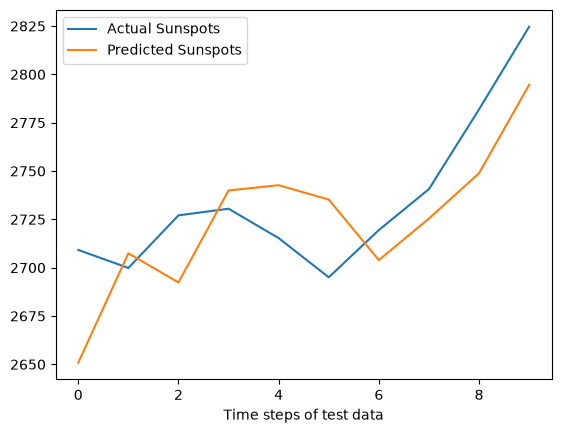

r2_score:  0.33809219484471


In [8]:
plt.plot(X_test_orig)
plt.plot(fcst)
plt.legend(['Actual Sunspots', 'Predicted Sunspots'])
plt.xlabel('Time steps of test data')
plt.show()
print("r2_score: ", r2_score(X_test_orig,fcst))

This is sooo much better. We will try other hyperparameters. For now lets see how well it works with the sector returns.

In [12]:
import pmdarima as pm

# This automatically finds the best p, d, and q for your trended data
model = pm.auto_arima(fin_data['weighted_sector_returns'], 
                      d=None,           # Let the algorithm find the best 'd'
                      seasonal=True,   # Set to True if you also have seasonal patterns
                      stepwise=True)

print(model.summary()) # This will show you the chosen p, d, q values


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2263
Model:               SARIMAX(0, 0, 1)   Log Likelihood               -4245.795
Date:                Sun, 23 Aug 2026   AIC                           8497.589
Time:                        11:41:33   BIC                           8514.763
Sample:                             0   HQIC                          8503.856
                               - 2263                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1607      0.039      4.111      0.000       0.084       0.237
ma.L1          0.1771      0.009     18.975      0.000       0.159       0.195
sigma2         2.4955      0.032     78.903      0.0

Lets work with SARIMAX(0, 0, 1)

In [15]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Showing the test prediction of the final model
data_array = fin_data['weighted_sector_returns'].to_numpy().reshape(-1, 1)
X_train, X_test = data_array[:-10], data_array[-10:]
X_test_orig = X_test
fcst = []

for step in range(10):
    mod = ARIMA(X_train, order=(0,0,1))
    res = mod.fit()
    fcst.append(res.forecast(steps=1))
    X_train = np.concatenate((X_train, X_test[0:1,:]))
    X_test = X_test[1:]

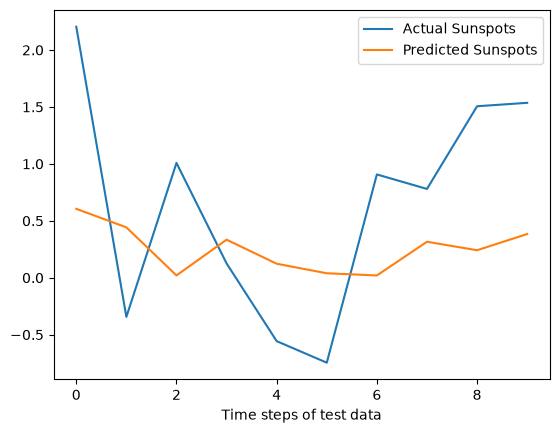

r2_score:  -0.04428741361142774


In [16]:
plt.plot(X_test_orig)
plt.plot(fcst)
plt.legend(['Actual Sunspots', 'Predicted Sunspots'])
plt.xlabel('Time steps of test data')
plt.show()
print("r2_score: ", r2_score(X_test_orig,fcst))

It learned better from the trend data. So how do we improve it. Lets improve the max of each parameter.

In [17]:
import pmdarima as pm

# This automatically finds the best p, d, and q for your trended data
model = pm.auto_arima(fin_data['sector_index'], 
                      d=None,           # Let the algorithm find the best 'd'
                      max_P=10, start_p=1,
                      max_d=10, 
                      max_q=10, start_q=1,
                      seasonal=False,   # Set to True if you also have seasonal patterns
                      stepwise=True)

print(model.summary()) # This will show you the chosen p, d, q values


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2263
Model:               SARIMAX(5, 2, 0)   Log Likelihood               -9256.569
Date:                Sun, 23 Aug 2026   AIC                          18525.138
Time:                        11:56:40   BIC                          18559.479
Sample:                             0   HQIC                         18537.669
                               - 2263                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6990      0.008    -88.737      0.000      -0.714      -0.684
ar.L2         -0.6463      0.011    -59.757      0.000      -0.668      -0.625
ar.L3         -0.4937      0.013    -39.383      0.0

Its the same. Lets move on.

In [19]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')

data_array = fin_data['sector_index'].to_numpy().reshape(-1, 1)
avg_errors = []

for p in range(6):
    for q in range(3):
        for i in range(5):
            errors = []
            tscv = TimeSeriesSplit(test_size=10)

            for train_index, test_index in tscv.split(data_array):
                X_train = data_array[train_index]
                X_test = data_array[test_index]
                X_test_orig = X_test.copy()
                fcst = []

                for step in range(10):
                    try:
                        mod = ARIMA(X_train, order=(p, i, q))
                        res = mod.fit()

                        # Convert forecast from array to scalar
                        forecast = res.forecast(steps=1)[0]
                        fcst.append(forecast)

                    except Exception as e:
                        print(f"Error for p={p}, i={i}, q={q}, step={step}: {e}")

                        # Use a scalar here as well
                        fcst.append(np.nan)

                    # Add actual observation to training data
                    X_train = np.concatenate(
                        (X_train, X_test[0:1, :])
                    )

                    # Remove first test observation
                    X_test = X_test[1:]

                # Convert actual values to 1D
                y_true = X_test_orig.ravel()

                # Convert forecasts to 1D
                y_pred = np.array(fcst)

                # Don't calculate R² if a model failed
                if np.isnan(y_pred).any():
                    errors.append(np.nan)
                else:
                    errors.append(r2_score(y_true, y_pred))

            pq_result = [p, i, q, np.nanmean(errors)]
            print(pq_result)
            avg_errors.append(pq_result)

[0, 0, 0, np.float64(-1608.1446182406326)]
[0, 1, 0, np.float64(0.5693287514112593)]
[0, 2, 0, np.float64(0.3439805530816028)]
[0, 3, 0, np.float64(-0.8059758009922888)]
[0, 4, 0, np.float64(-4.591510577637024)]
[0, 0, 1, np.float64(-456.73347489933786)]
[0, 1, 1, np.float64(0.5957376321690979)]
[0, 2, 1, np.float64(0.5416865769192253)]
[0, 3, 1, np.float64(0.34364269486590443)]
[0, 4, 1, np.float64(-0.8070334080728567)]
[0, 0, 2, np.float64(-130.08693874213594)]
[0, 1, 2, np.float64(0.5951425987545678)]
[0, 2, 2, np.float64(0.5943279887820173)]
[0, 3, 2, np.float64(0.5396901709809343)]
[0, 4, 2, np.float64(0.3535679543900635)]
[1, 0, 0, np.float64(0.5690407982738267)]
[1, 1, 0, np.float64(0.5913500201239374)]
[1, 2, 0, np.float64(0.40121965332819104)]
[1, 3, 0, np.float64(-0.294571072016443)]
[1, 4, 0, np.float64(-2.3450668613808054)]
[1, 0, 1, np.float64(0.595368912868105)]
[1, 1, 1, np.float64(0.5952198152699134)]
[1, 2, 1, np.float64(0.5898011548140042)]
[1, 3, 1, np.float64(0.4009

In [20]:
import pandas as pd

avg_errors = pd.DataFrame(avg_errors)
avg_errors.columns = ['p', 'i', 'q', 'error']
result=avg_errors.sort_values('error', ascending=False)

In [21]:
result

,p,i,q,error
26,1,1,2,6.003491e-01
6,0,1,1,5.957376e-01
20,1,0,1,5.953689e-01
21,1,1,1,5.952198e-01
11,0,1,2,5.951426e-01
...,...,...,...,...
30,2,0,0,-8.663468e+03
58,3,3,2,-1.500587e+12
73,4,3,2,-1.007576e+18
89,5,4,2,-4.821228e+22


from this (1,1,2) is the best hyperprameter. We will train with both Timeseriescv and train_test_split to view its performance

#### train_test_split

In [22]:
data_array

array([[ 100.        ],
       [ 100.35343188],
       [ 100.17056456],
       ...,
       [2740.66803716],
       [2781.93957376],
       [2824.67076352]], shape=(2263, 1))

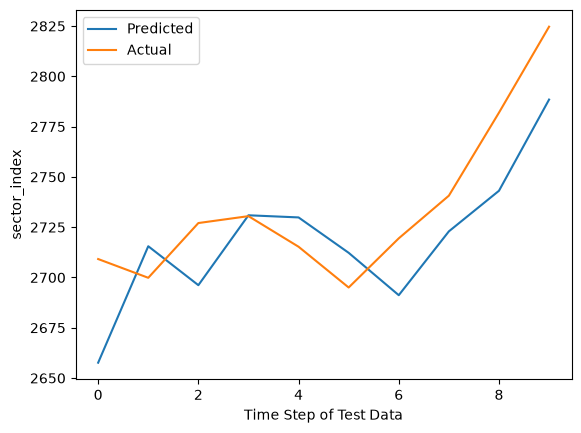

r2_score:  0.42708355785610885


In [23]:
# Plot the final result

X_train, X_test = data_array[:-10], data_array[-10:]
X_test_orig = X_test

fcst = []
for step in range(10):
    mod = ARIMA(X_train, order=(1,1,2))
    res = mod.fit()
    fcst.append(res.forecast(steps=1))
    X_train = np.concatenate((X_train, X_test[0:1,:]))
    X_test = X_test[1:]
plt.plot(fcst)
plt.plot(X_test_orig)
plt.legend(['Predicted', 'Actual'])
plt.ylabel('sector_index')
plt.xlabel('Time Step of Test Data')
plt.show()
print('r2_score: ', r2_score(X_test_orig,fcst))

Not very good but better. Now:

#### TimeSeriesSplitCV

c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


R² Score: 0.9153933861861201
RMSE: 36.54069598599981
MAE: 28.233049424479514


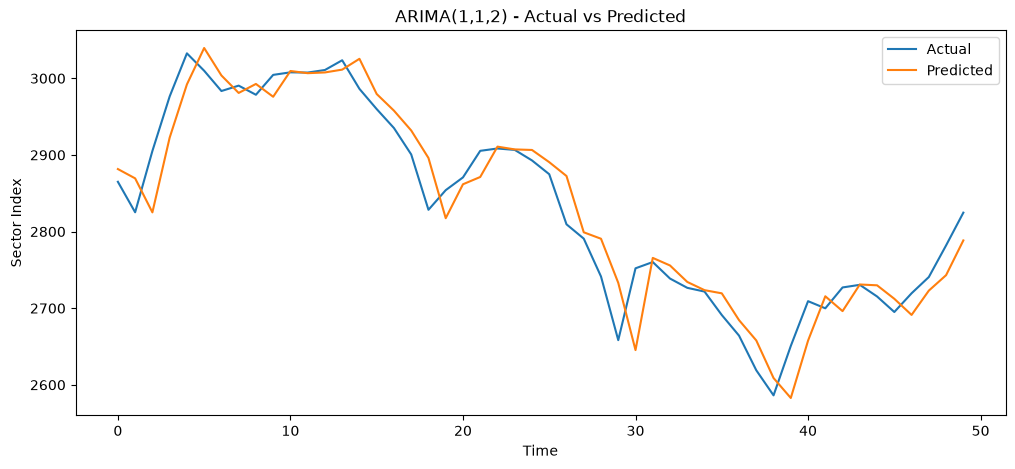

In [6]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

data_array = fin_data['sector_index'].to_numpy().reshape(-1, 1)

tscv = TimeSeriesSplit(test_size=10)

actual = []
predicted = []

steps = 10

for train_index, test_index in tscv.split(data_array):

    train = data_array[train_index]
    test = data_array[test_index]

    # Keep the original test values
    test_original = test.copy()

    for step in range(steps):

        # Train ARIMA(1,1,2)
        model = ARIMA(train, order=(1, 1, 2))
        results = model.fit()

        # One-step-ahead forecast
        forecast = results.forecast(steps=1)[0]

        predicted.append(forecast)

        # Add actual observation to training data
        train = np.concatenate(
            (train, test[0:1])
        )

        # Remove the observation we just predicted
        test = test[1:]

    # Store the original actual values
    actual.extend(test_original)

# Convert to arrays
actual = np.array(actual)
predicted = np.array(predicted)

# R² across all test observations
r2 = r2_score(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

# Plot
plt.figure(figsize=(12, 5))

plt.plot(actual, label="Actual")
plt.plot(predicted, label="Predicted")

plt.xlabel("Time")
plt.ylabel("Sector Index")
plt.title("ARIMA(1,1,2) - Actual vs Predicted")
plt.legend()

plt.show()

This tells us that the model does very well at predicting the next day's price.

c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


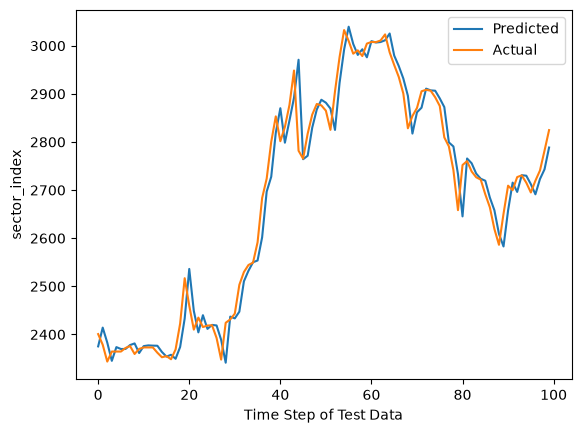

R² Score: 0.9153933861861201
RMSE: 36.54069598599981
MAE: 28.233049424479514


In [8]:
# Plot the final result

X_train, X_test = data_array[:-100], data_array[-100:]
X_test_orig = X_test

fcst = []
for step in range(100):
    mod = ARIMA(X_train, order=(1,1,2))
    res = mod.fit()
    fcst.append(res.forecast(steps=1))
    X_train = np.concatenate((X_train, X_test[0:1,:]))
    X_test = X_test[1:]

plt.plot(fcst)
plt.plot(X_test_orig)
plt.legend(['Predicted', 'Actual'])
plt.ylabel('sector_index')
plt.xlabel('Time Step of Test Data')
plt.show()

r2 = r2_score(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Let us see the training performance. That is how well the model is fitted.

Train R² Score: 0.9995550762811483
Train RMSE: 13.873773720287886
Train MAE: 6.1570681962621885


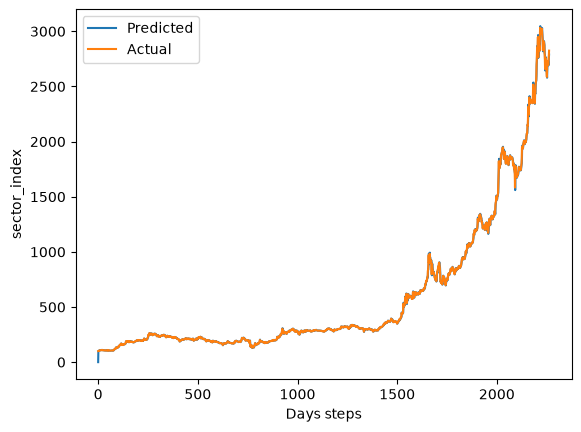

In [9]:
# Fitting the ARMA(1,1) model
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Forecast the first ARMA(1,1) model
mod = ARIMA(list(fin_data['sector_index']), order=(1,1,2))
res = mod.fit()
pred = res.predict()
## NOTE: we didnt split the data so we are not forcasting. We will see how well the model fits the train data (entire data)
r2=r2_score(fin_data['sector_index'], pred)
rmse = np.sqrt(mean_squared_error(fin_data['sector_index'], pred))
mae = mean_absolute_error(fin_data['sector_index'], pred)

print("Train R² Score:", r2)
print("Train RMSE:", rmse)
print("Train MAE:", mae)

plt.plot(pred)
plt.plot(fin_data['sector_index'])
plt.legend(['Predicted', 'Actual'])
plt.ylabel('sector_index')
plt.xlabel('Days steps')
plt.show()